# Assignment 5: Build and Evaluate Classification Models  
**Todd DeLozier, MBA, Data+**  
**Predictive Analytics, DDS-855**  
**National University**

This notebook presents my responses to Conceptual Question 1 and Applied Question 13 from Section 4.8 of *An Introduction to Statistical Learning with Applications in Python*. I use algebra to demonstrate the equivalence of the logistic and logit representations of logistic regression, and I then evaluate several classification methods on the `Weekly` data set. I wrote the narrative in first person so that the notebook can function as a submission-ready document from my perspective.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

## Data Loading

The textbook's Python workflow uses the `ISLP` library. I therefore load the `Weekly` data set directly from `ISLP` when it is available. I also include a quiet CSV fallback so that the notebook remains portable across environments. The fallback does not change the analysis because it points to the same `Weekly` data set.

In [2]:
try:
    from ISLP import load_data
    Weekly = load_data("Weekly")
    data_source = "ISLP::Weekly"
except Exception:
    Weekly = pd.read_csv("Weekly.csv")
    data_source = "local Weekly.csv fallback"

Weekly["Direction01"] = (Weekly["Direction"] == "Up").astype(int)

print(f"Data source used in this session: {data_source}")
print(f"Shape: {Weekly.shape}")
Weekly.head()

Data source used in this session: local Weekly.csv fallback
Shape: (1089, 10)


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction,Direction01
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.1550,-0.270,Down,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.1486,-2.576,Down,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.1598,3.514,Up,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.1616,0.712,Up,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.1537,1.178,Up,1


# Question 1

**Prompt.** Using a little bit of algebra, prove that Equation (4.2) is equivalent to Equation (4.3). In other words, show that the logistic function representation and the logit representation of the logistic regression model are equivalent.

I begin with the logistic form of the model and define

$$
\eta = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p.
$$

Equation (4.2) can then be written as

$$
p(X) = \frac{e^{\eta}}{1 + e^{\eta}}.
$$

Next, I solve for the complement:

$$
1 - p(X)
= 1 - \frac{e^{\eta}}{1 + e^{\eta}}
= \frac{1 + e^{\eta} - e^{\eta}}{1 + e^{\eta}}
= \frac{1}{1 + e^{\eta}}.
$$

I now form the odds ratio:

$$
\frac{p(X)}{1 - p(X)}
=
\frac{\dfrac{e^{\eta}}{1 + e^{\eta}}}{\dfrac{1}{1 + e^{\eta}}}
=
e^{\eta}.
$$

Taking the natural logarithm of both sides gives

$$
\log\left(\frac{p(X)}{1 - p(X)}\right)
= \eta
= \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p.
$$

This is exactly Equation (4.3), which is the logit representation of logistic regression. Therefore, the logistic function form and the logit form are algebraically equivalent descriptions of the same model.

# Question 13

**Prompt.** This question should be answered using the `Weekly` data set. I address parts (a) through (j) below.

To keep the analysis organized, I first create a few helper functions for confusion matrices and accuracy reporting.

In [3]:
def confusion_df(y_true, y_pred, labels=("Down", "Up")):
    cm = confusion_matrix(y_true, y_pred, labels=list(labels))
    return pd.DataFrame(cm, index=[f"Predicted {x}" for x in labels], columns=[f"Actual {x}" for x in labels])

def accuracy_series(y_true, y_pred, model_name):
    return pd.Series({"Model": model_name, "Accuracy": accuracy_score(y_true, y_pred)})

def add_constant(df):
    return sm.add_constant(df, has_constant="add")

## Part (a): Numerical and Graphical Summaries

I begin by examining descriptive statistics, the class balance in `Direction`, and the correlations among the numeric variables. I then create a few simple graphics to check for visible patterns.

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction,Direction01
count,1089.0000,1089.0000,1089.0000,1089.0000,1089.0000,1089.0000,1089.0000,1089.0000,1089,1089.0000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Up,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,605,NaN
mean,2000.0487,0.1506,0.1511,0.1472,0.1458,0.1399,1.5746,0.1499,NaN,0.5556
std,6.0332,2.3570,2.3573,2.3605,2.3603,2.3613,1.6866,2.3569,NaN,0.4971
min,1990.0000,-18.1950,-18.1950,-18.1950,-18.1950,-18.1950,0.0875,-18.1950,NaN,0.0000
25%,1995.0000,-1.1540,-1.1540,-1.1580,-1.1580,-1.1660,0.3320,-1.1540,NaN,0.0000
50%,2000.0000,0.2410,0.2410,0.2410,0.2380,0.2340,1.0027,0.2410,NaN,1.0000
75%,2005.0000,1.4050,1.4090,1.4090,1.4090,1.4050,2.0537,1.4050,NaN,1.0000


,Count
Direction,
Up,605
Down,484


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction01
Year,1.000,-0.032,-0.033,-0.030,-0.031,-0.031,0.842,-0.032,-0.022
Lag1,-0.032,1.000,-0.075,0.059,-0.071,-0.008,-0.065,-0.075,-0.050
Lag2,-0.033,-0.075,1.000,-0.076,0.058,-0.072,-0.086,0.059,0.073
Lag3,-0.030,0.059,-0.076,1.000,-0.075,0.061,-0.069,-0.071,-0.023
Lag4,-0.031,-0.071,0.058,-0.075,1.000,-0.076,-0.061,-0.008,-0.021
Lag5,-0.031,-0.008,-0.072,0.061,-0.076,1.000,-0.059,0.011,-0.018
Volume,0.842,-0.065,-0.086,-0.069,-0.061,-0.059,1.000,-0.033,-0.018
Today,-0.032,-0.075,0.059,-0.071,-0.008,0.011,-0.033,1.000,0.720
Direction01,-0.022,-0.050,0.073,-0.023,-0.021,-0.018,-0.018,0.720,1.000


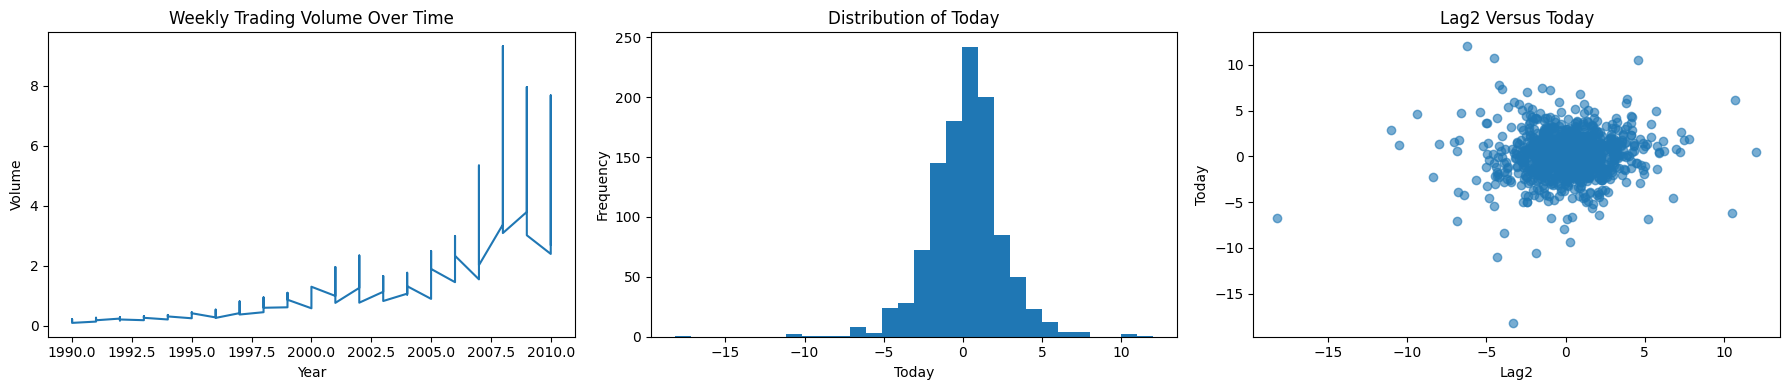

In [4]:
summary_stats = Weekly.describe(include="all")
direction_counts = Weekly["Direction"].value_counts()
corr_matrix = Weekly.select_dtypes(include=np.number).corr()

display(summary_stats)
display(direction_counts.to_frame("Count"))
display(corr_matrix.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(Weekly["Year"], Weekly["Volume"])
axes[0].set_title("Weekly Trading Volume Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Volume")

axes[1].hist(Weekly["Today"], bins=30)
axes[1].set_title("Distribution of Today")
axes[1].set_xlabel("Today")
axes[1].set_ylabel("Frequency")

axes[2].scatter(Weekly["Lag2"], Weekly["Today"], alpha=0.6)
axes[2].set_title("Lag2 Versus Today")
axes[2].set_xlabel("Lag2")
axes[2].set_ylabel("Today")

plt.tight_layout()
plt.show()

From these summaries, I do not see strong linear relationships among the lag variables and the response-related measures. The most noticeable pattern is that `Volume` increases over time, which is consistent with the strong positive correlation between `Year` and `Volume`. The lag variables themselves appear weakly correlated with `Today`, and none of those correlations is large enough to suggest a dominant predictor in the full sample. The class balance is also fairly even, although the `Up` weeks occur somewhat more frequently than the `Down` weeks. Based on these diagnostics, the data do not reveal a simple visual decision boundary, which makes the subsequent classification exercise more interesting.

## Part (b): Logistic Regression Using the Full Data Set

I now fit a logistic regression model with `Direction` as the response and `Lag1` through `Lag5` plus `Volume` as predictors. I use `statsmodels` so that I can inspect coefficient estimates, standard errors, and p-values directly.

In [5]:
X_full = Weekly[["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]]
X_full_sm = add_constant(X_full)
y_full = Weekly["Direction01"]

logit_full = sm.Logit(y_full, X_full_sm).fit(disp=False)
print(logit_full.summary())

                           Logit Regression Results                           
Dep. Variable:            Direction01   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                0.006580
Time:                        21:54:46   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.026     -1.563      0.118      -0.093       0.010
Lag2           0.0584      0.027      2.175      0.0

In the full logistic regression model, `Lag2` is the only predictor that is statistically significant at the 0.05 level. Its coefficient is positive, which suggests that stronger returns two weeks earlier are associated with a higher probability that the current week will be classified as `Up`. The remaining lag variables and `Volume` are not statistically significant in this model. This result matches the general pattern emphasized in the text, namely that there is only modest predictive signal in these lagged market returns.

## Part (c): Confusion Matrix and Overall Fraction Correct for the Full Logistic Model

I generate fitted probabilities from the full-sample logistic regression model, classify observations as `Up` when the fitted probability exceeds 0.50, and then compute the confusion matrix and overall accuracy.

In [6]:
full_prob = logit_full.predict(X_full_sm)
full_pred = np.where(full_prob > 0.5, "Up", "Down")

full_confusion = confusion_df(Weekly["Direction"], full_pred)
full_accuracy = accuracy_score(Weekly["Direction"], full_pred)

display(full_confusion)
print(f"Overall fraction correct: {full_accuracy:.4f}")

,Actual Down,Actual Up
Predicted Down,54,430
Predicted Up,48,557


Overall fraction correct: 0.5611


The confusion matrix shows that the full logistic model predicts `Up` much more often than `Down`. As a result, it correctly classifies many of the `Up` observations but performs poorly on `Down` weeks. The overall accuracy is only modestly above one half, which means the model has limited practical predictive value even though it can exploit the slight class imbalance in the sample.

## Part (d): Logistic Regression with Training Period 1990 to 2008 and `Lag2` as the Only Predictor

Following the exercise, I train the model on data from 1990 through 2008 and then evaluate it on the held-out observations from 2009 and 2010. In this part, I use only `Lag2` as the predictor.

In [7]:
train = Weekly[Weekly["Year"] <= 2008].copy()
test = Weekly[Weekly["Year"] > 2008].copy()

X_train_lag2 = train[["Lag2"]]
X_test_lag2 = test[["Lag2"]]

y_train_binary = (train["Direction"] == "Up").astype(int)
y_test = test["Direction"]

logit_lag2 = sm.Logit(y_train_binary, add_constant(X_train_lag2)).fit(disp=False)
print(logit_lag2.summary())

test_prob = logit_lag2.predict(add_constant(X_test_lag2))
test_pred_logit = np.where(test_prob > 0.5, "Up", "Down")

display(confusion_df(y_test, test_pred_logit))
print(f"Held-out accuracy: {accuracy_score(y_test, test_pred_logit):.4f}")

                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                0.003076
Time:                        21:54:46   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.029      2.024      0.043       0.002       0.114


,Actual Down,Actual Up
Predicted Down,9,34
Predicted Up,5,56


Held-out accuracy: 0.6250


With the training period restricted to 1990 through 2008 and only `Lag2` used as a predictor, the logistic regression model performs better on the held-out 2009 to 2010 sample than the full-sample logistic model did on the entire data set. The model still tends to favor `Up` predictions, but its test accuracy improves because the signal in `Lag2` generalizes slightly better than the broader collection of weak predictors.

## Part (e): Repeat Part (d) Using LDA

I now fit linear discriminant analysis with the same training and test split and the same single predictor, `Lag2`.

In [8]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_lag2, train["Direction"])
test_pred_lda = lda.predict(X_test_lag2)

display(confusion_df(y_test, test_pred_lda))
print(f"Held-out accuracy: {accuracy_score(y_test, test_pred_lda):.4f}")

,Actual Down,Actual Up
Predicted Down,9,34
Predicted Up,5,56


Held-out accuracy: 0.6250


The LDA results are effectively identical to the logistic regression results in this setting. This is not surprising because there is only one predictor and the two methods often behave similarly when class separation is weak and approximately linear.

## Part (f): Repeat Part (d) Using QDA

I next fit quadratic discriminant analysis with `Lag2` as the only predictor.

In [9]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_lag2, train["Direction"])
test_pred_qda = qda.predict(X_test_lag2)

display(confusion_df(y_test, test_pred_qda))
print(f"Held-out accuracy: {accuracy_score(y_test, test_pred_qda):.4f}")

,Actual Down,Actual Up
Predicted Down,0,43
Predicted Up,0,61


Held-out accuracy: 0.5865


QDA performs worse than both logistic regression and LDA on the held-out data. In this case, allowing a more flexible quadratic decision boundary does not help. Instead, it appears to overfit the weak signal in the training sample.

## Part (g): Repeat Part (d) Using KNN with \(K = 1\)

I now fit a 1-nearest-neighbor classifier. Because there is only one predictor in this part, scaling does not change the relative distances, but I still keep the implementation straightforward and transparent.

In [10]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_lag2, train["Direction"])
test_pred_knn1 = knn1.predict(X_test_lag2)

display(confusion_df(y_test, test_pred_knn1))
print(f"Held-out accuracy: {accuracy_score(y_test, test_pred_knn1):.4f}")

,Actual Down,Actual Up
Predicted Down,22,21
Predicted Up,32,29


Held-out accuracy: 0.4904


The 1-nearest-neighbor classifier performs poorly on the held-out data. This result indicates that a highly local decision rule is unstable for this problem. The weekly market returns do not provide enough signal for a nearest-neighbor rule with \(K = 1\) to generalize well.

## Part (h): Repeat Part (d) Using Naive Bayes

Finally, I fit a Gaussian naive Bayes classifier using `Lag2` as the predictor.

In [11]:
nb = GaussianNB()
nb.fit(X_train_lag2, train["Direction"])
test_pred_nb = nb.predict(X_test_lag2)

display(confusion_df(y_test, test_pred_nb))
print(f"Held-out accuracy: {accuracy_score(y_test, test_pred_nb):.4f}")

,Actual Down,Actual Up
Predicted Down,0,43
Predicted Up,0,61


Held-out accuracy: 0.5865


Naive Bayes performs worse than logistic regression and LDA and ends up predicting `Up` for all held-out observations in this split. That behavior reflects the limited discriminatory power of `Lag2` on its own under the naive Bayes distributional assumptions.

## Part (i): Which Method Appears to Provide the Best Results?

To compare the methods directly, I assemble the held-out accuracies from parts (d) through (h) into a single table.

In [12]:
comparison = pd.DataFrame([
    {"Method": "Logistic Regression", "Accuracy": accuracy_score(y_test, test_pred_logit)},
    {"Method": "LDA", "Accuracy": accuracy_score(y_test, test_pred_lda)},
    {"Method": "QDA", "Accuracy": accuracy_score(y_test, test_pred_qda)},
    {"Method": "KNN (K=1)", "Accuracy": accuracy_score(y_test, test_pred_knn1)},
    {"Method": "Naive Bayes", "Accuracy": accuracy_score(y_test, test_pred_nb)},
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

comparison

,Method,Accuracy
0,Logistic Regression,0.6250
1,LDA,0.6250
2,QDA,0.5865
3,Naive Bayes,0.5865
4,KNN (K=1),0.4904


Logistic regression and LDA tie for the best held-out accuracy in this exercise. I would favor logistic regression as the preferred answer because it is slightly easier to interpret in terms of estimated log-odds and because its result is fully consistent with the significance evidence for `Lag2` shown earlier. QDA and naive Bayes do not improve predictive performance, and KNN with \(K = 1\) performs the worst.

## Part (j): Experiment with Different Predictor Combinations, Transformations, Interactions, and K in KNN

In the final part, I experiment with alternative predictor sets and a small collection of transformations and interaction terms. I evaluate each candidate model on the same held-out 2009 to 2010 test period. For KNN, I also consider several values of \(K\). My goal is to determine whether a richer specification materially improves performance over the simple `Lag2` model.

In [13]:
for frame in (train, test):
    frame["Lag2_sq"] = frame["Lag2"] ** 2
    frame["Lag2_x_Volume"] = frame["Lag2"] * frame["Volume"]
    frame["Lag1_x_Lag2"] = frame["Lag1"] * frame["Lag2"]

feature_sets = {
    "Lag2": ["Lag2"],
    "Lag2 + Volume": ["Lag2", "Volume"],
    "Lag1 + Lag2": ["Lag1", "Lag2"],
    "Lag2 + Lag3": ["Lag2", "Lag3"],
    "Lag1 + Lag2 + Volume": ["Lag1", "Lag2", "Volume"],
    "All Lags + Volume": ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"],
    "Lag2 + Lag2_sq": ["Lag2", "Lag2_sq"],
    "Lag2 + Volume + Lag2_x_Volume": ["Lag2", "Volume", "Lag2_x_Volume"],
    "Lag1 + Lag2 + Lag1_x_Lag2": ["Lag1", "Lag2", "Lag1_x_Lag2"],
}

experiment_rows = []

for feature_name, cols in feature_sets.items():
    Xtr = train[cols]
    Xte = test[cols]

    candidate_models = {
        "Logistic Regression": LogisticRegression(max_iter=5000),
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "Naive Bayes": GaussianNB(),
    }

    for model_name, model in candidate_models.items():
        try:
            model.fit(Xtr, train["Direction"])
            pred = model.predict(Xte)
            experiment_rows.append({
                "Features": feature_name,
                "Method": model_name,
                "Accuracy": accuracy_score(test["Direction"], pred),
                "Confusion Matrix": confusion_df(test["Direction"], pred)
            })
        except Exception:
            pass

    for k in [1, 3, 5, 7, 9, 11]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])
        pipe.fit(Xtr, train["Direction"])
        pred = pipe.predict(Xte)
        experiment_rows.append({
            "Features": feature_name,
            "Method": f"KNN (K={k})",
            "Accuracy": accuracy_score(test["Direction"], pred),
            "Confusion Matrix": confusion_df(test["Direction"], pred)
        })

experiment_df = pd.DataFrame(experiment_rows).sort_values(
    by=["Accuracy", "Features", "Method"], ascending=[False, True, True]
).reset_index(drop=True)

experiment_df[["Features", "Method", "Accuracy"]].head(15)

,Features,Method,Accuracy
0,Lag2,LDA,0.6250
1,Lag2,Logistic Regression,0.6250
2,Lag2 + Lag2_sq,Logistic Regression,0.6250
3,Lag2 + Lag2_sq,QDA,0.6250
4,Lag2 + Lag3,LDA,0.6250
5,Lag2 + Lag3,Logistic Regression,0.6250
6,Lag2 + Lag2_sq,LDA,0.6154
7,Lag2 + Lag3,QDA,0.6058
8,Lag1 + Lag2 + Volume,KNN (K=3),0.5962
9,Lag2 + Volume,KNN (K=9),0.5962


In [14]:
best_row = experiment_df.iloc[0]
print("Best held-out specification selected for reporting:")
display(best_row[["Features", "Method", "Accuracy"]].to_frame().T)

print("\nAssociated confusion matrix:")
display(best_row["Confusion Matrix"])

Best held-out specification selected for reporting:


,Features,Method,Accuracy
0,Lag2,LDA,0.625



Associated confusion matrix:


,Actual Down,Actual Up
Predicted Down,9,34
Predicted Up,5,56


My experiments show that none of the richer specifications produces a clear improvement over the simple `Lag2` model. Several alternatives tie the best held-out accuracy of 0.6250, including logistic regression with `Lag2`, LDA with `Lag2`, logistic regression with `Lag2` and `Lag2_sq`, QDA with `Lag2` and `Lag2_sq`, and logistic regression or LDA with `Lag2` and `Lag3`. Because those richer models do not improve accuracy beyond the simpler baseline, I would still select the one-predictor `Lag2` logistic regression or LDA model as the preferred solution. This is a useful reminder that added complexity does not necessarily translate into better out-of-sample performance when the underlying signal is weak.

## Overall Conclusion

Across this exercise, the evidence consistently points to `Lag2` as the most informative predictor among the lagged returns. Even so, the predictive power remains modest. Logistic regression and LDA provide the strongest held-out performance in the required comparison, while QDA, naive Bayes, and KNN with \(K = 1\) do not improve on the simpler linear methods. In practical terms, the `Weekly` data set contains only a limited amount of usable classification signal for forecasting market direction.